In [1]:
import os
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from scipy import stats

In [2]:
plt.rcParams['legend.markerscale'] = 1.5
plt.rcParams['legend.handletextpad'] = 0.5
plt.rcParams['legend.labelspacing'] = 0.4
plt.rcParams['legend.borderpad'] = 0.5
plt.rcParams['font.size'] = 12
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['axes.labelsize'] = 22
plt.rcParams['axes.titlesize'] = 24
plt.rcParams['figure.figsize'] = (10, 6)

plt.rc('xtick', labelsize=18)
plt.rc('ytick', labelsize=18)
plt.rc('legend', fontsize=22)

# 1. Генерация данных

In [3]:
def generate_data(sample_size, corr=0.8):
    """Генерируем две выборки с случайным сэмплированием.
    
    sample_size - размер выборки
    corr - корреляция метрики во время эксперимента с метрикой до эксперимента
    
    return - pd.DataFrame со столбцами ['metric', 'metric_before', 'factor'],
        'metric' - значение метрики во время эксперимента,
        'metric_before' - значение метрики до время эксперимента.
    """
    means = [5, 5]
    cov = [[1, corr], [corr, 1]]
    data = np.random.multivariate_normal(means, cov, sample_size)
    df = pd.DataFrame({'metric': data[:, 0], 'metric_before': data[:, 1]})
    return df

In [4]:
df = generate_data(5, 0.6)
df

,metric,metric_before
0,4.364013,5.561109
1,4.295040,4.474431
2,5.514208,7.027549
3,6.210948,6.349229
4,4.645607,5.131041


In [5]:
df.corr().round(3)

,metric,metric_before
metric,1.000,0.787
metric_before,0.787,1.000


# 2. Оценка $\theta$
$$\hat{Y}_{CV} = \overline{Y} - \theta \overline{X} + \theta\mathbb{E}X$$

$$\hat{Y}_{CV, i} = Y_i - \theta X_i + \theta\mathbb{E}X$$


Формула для оптимального значения $\theta$:

$$\theta = \frac{\mathrm{cov}(Y,X)}{\mathbb{V} X}$$

In [6]:
def calculate_theta(y_control, y_pilot, x_control, x_pilot):
    """Вычисляем Theta по данным двух групп.

    y_control - значения метрики во время пилота на контрольной группе
    y_pilot - значения метрики во время пилота на пилотной группе
    x_control - значения ковариант на контрольной группе
    x_pilot - значения ковариант на пилотной группе
    """
    y = np.hstack([y_control, y_pilot])
    x = np.hstack([x_control, x_pilot])
    covariance = np.cov(x, y)[0, 1]
    variance = x.var()
    theta = covariance / variance
    return theta

Посмотрим, как работает функция. Сгенерируем два датасета, к одному из них добавим эффект, вычислим $\theta$.

In [7]:
sample_size = 100
df_control = generate_data(sample_size)
df_pilot = generate_data(sample_size)
df_pilot['metric'] += np.random.normal(0.2, 0.1, sample_size)

theta = calculate_theta(
    df_control['metric'], df_pilot['metric'],
    df_control['metric_before'], df_pilot['metric_before']
)
print(f'theta = {theta}')

theta = 0.7655664946408416


Проверим, действительно ли при таком значении $\theta$ достигается минимум дисперсии. Для этого вычислим преобразованную метрику и построим график её дисперсии в зависимости от $\theta$ для пилотной и контрольной групп.

  0%|          | 0/1000 [00:00<?, ?it/s]

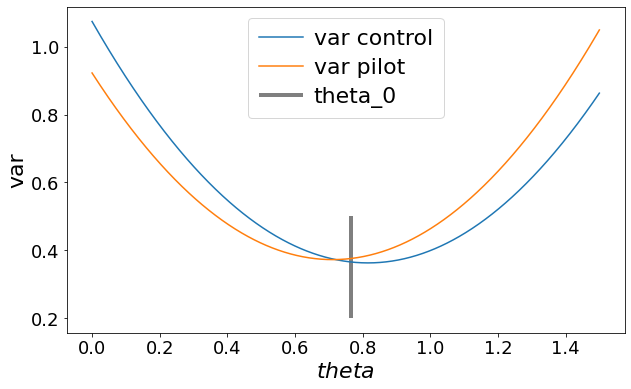

In [8]:
thetas = np.linspace(0, 1.5, 1000)
list_var_control = []
list_var_pilot = []

for theta_ in tqdm(thetas):
    y_cuped_control = df_control['metric'] - theta_ * df_control['metric_before']
    y_cuped_pilot = df_pilot['metric'] - theta_ * df_pilot['metric_before']
    list_var_control.append(y_cuped_control.var())
    list_var_pilot.append(y_cuped_pilot.var())

plt.plot(thetas, list_var_control, label='var control')
plt.plot(thetas, list_var_pilot, label='var pilot')
plt.vlines(theta, 0.2, 0.5, label='theta_0', linewidth=4, alpha=0.5)
plt.xlabel('$theta$')
plt.ylabel('var')
plt.legend()
plt.show()

Действительно, значение $\theta$, найденное по формуле, близко к оптимальным значениям с минимальными дисперсиями.

# 3. Оценка экспериментов

In [9]:
def check_test(df_control, df_pilot):
    """Проверяет гипотезу о равенстве средних с помощью t-test.

    return - pvalue.
    """
    values_control = df_control['metric'].values
    values_pilot = df_pilot['metric'].values
    _, pvalue = stats.ttest_ind(values_control, values_pilot)
    return pvalue


def check_cuped_test(df_control, df_pilot, covariate_column):
    """Проверяет гипотезу о равенстве средних с использованием CUPED.

    covariate_column - название стобца с ковариантой

    return - pvalue.
    """
    theta = calculate_theta(
        df_control['metric'], df_pilot['metric'],
        df_control[covariate_column], df_pilot[covariate_column]
    )
    metric_cuped_control = df_control['metric'] - theta * df_control[covariate_column]
    metric_cuped_pilot = df_pilot['metric'] - theta * df_pilot[covariate_column]
    _, pvalue = stats.ttest_ind(metric_cuped_control, metric_cuped_pilot)
    return pvalue

Посмотрим, как работает `check_cuped_test`. Мы создавали пару датафреймов `df_control`, `df_pilot` с наличием эффекта в пилотной группе. Применим `check_test` и `check_cuped_test` к этим данным.

In [10]:
pvalue_ttest = check_test(df_control, df_pilot)
pvalue_cuped = check_cuped_test(df_control, df_pilot, 'metric_before')
print(f'pvalue_ttest = {pvalue_ttest:0.3f}')
print(f'pvalue_cuped = {pvalue_cuped:0.3f}')

pvalue_ttest = 0.743
pvalue_cuped = 0.588


p-value при применении CUPED стало меньше, чувствительность увеличилась.

## Оценка вероятностей ошибок первого рода

Проведём много A/A тестов с различными значениями корреляции целевой метрики и ковариаты, затем построим распределение p-value. P-value должно быть распределено равномерно.

  0%|          | 0/1000 [00:00<?, ?it/s]

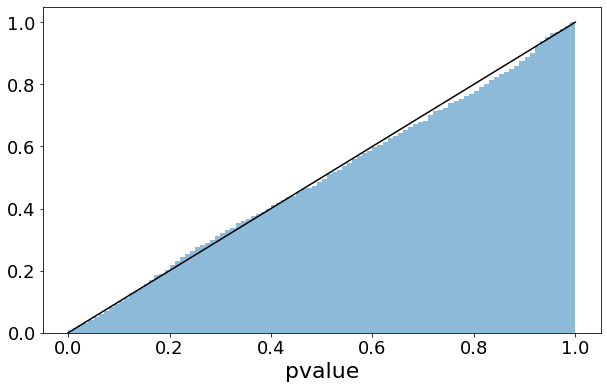

In [11]:
sample_size = 1000
pvalues_cuped = []
corrs = np.random.uniform(-1, 1, 1000)

for corr in tqdm(corrs):
    df_control = generate_data(sample_size, corr)
    df_pilot = generate_data(sample_size, corr)
    pvalues_cuped.append(check_cuped_test(df_control, df_pilot, 'metric_before'))


plt.hist(pvalues_cuped, bins=100, density=True, cumulative=True, alpha=0.5)
plt.xlabel('pvalue')
plt.plot([0, 1], [0, 1], 'k')
plt.show()

P-value распределено равномерно.

## Сравнение мощности тестов

Проведём много синтетических A/B тестов и построим распределение p-value. Распределение p-value должно быть выпуклым вверх. Чем более оно выпукло, тем мощнее тест.

  0%|          | 0/1000 [00:00<?, ?it/s]

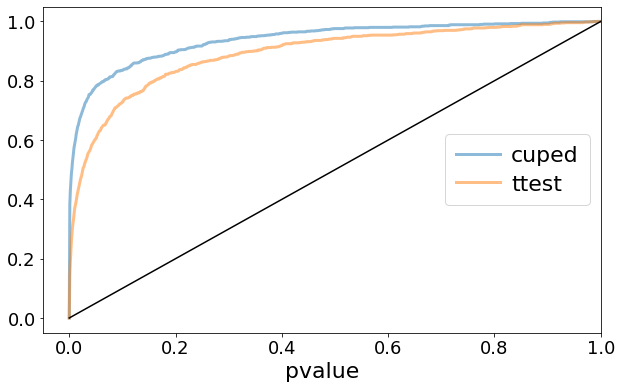

In [12]:
sample_size = 1000
pvalues_ttest = []
pvalues_cuped = []
corrs = np.random.uniform(0.01, 0.99, 1000)

for corr in tqdm(corrs):
    df_control = generate_data(sample_size, corr)
    df_pilot = generate_data(sample_size, corr)
    df_pilot['metric'] += np.random.normal(0.1, 0.01, sample_size)
    pvalues_ttest.append(check_test(df_control, df_pilot))
    pvalues_cuped.append(check_cuped_test(df_control, df_pilot, 'metric_before'))


list_pvalues = [pvalues_ttest, pvalues_cuped]
list_titles = ['ttest', 'cuped']

X = np.linspace(0, 1, 1000)
for pvalues, title in zip(reversed(list_pvalues), reversed(list_titles)):
    pvalues = np.array(pvalues)
    Y = [np.mean(pvalues < x) for x in X]
    plt.plot(X, Y, alpha=0.5, linewidth=3, label=title)
plt.xlabel('pvalue')
plt.xlim([-0.05, 1])
plt.plot([0, 1], [0, 1], 'k')
plt.legend(loc=5)
plt.show()